In [1]:
######################## Plot Edy Viscosity PDF ########################
# The purpose of this script is to plot a a PDF of eddy viscosity
# for the different ROMS runs of the idealized Beaufort shelfbreak jet.
#
# Notes:
# - This script runs in xroms
# - This script heavily uses code from Dylan Schlichting 
#
##########################################################################

In [2]:
# Load in the packages
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as tick
import numpy as np
import xarray as xr
import pandas as pd
import xroms
import cartopy
from matplotlib.colors import BoundaryNorm
import cmocean.cm as cmo
import xarray as xr
from netCDF4 import Dataset
# from mpas_analysis.shared.io.utility import decode_strings
from glob import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
from matplotlib import ticker
from xhistogram.xarray import histogram
from matplotlib.ticker import FuncFormatter

import warnings 
warnings.filterwarnings("ignore") #turns off annoying warnings

In [3]:
# Define a function to load in the output
def open_mfroms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_mfnetcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

### Load in the Output

In [4]:
# Load in the model output

# Constant forcing, u3c4, k-epsilon
ds_ice_u3c4_keps, grid_u3c4_keps = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc'))
# Constant forcing, u3c4, k-epsilon
ds_ice_u3c4_keps_no_ice, grid_u3c4_keps_no_ice = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_no_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc'))
# Constant forcing, U3C4, gen
ds_ice_u3c4_gen, grid_u3c4_gen = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_gen_*.nc'))
# Constant forcing, U3C4, kkl
ds_ice_u3c4_kkl, grid_u3c4_kkl = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kkl_*.nc'))
# Constant forcing, U3C4, k-omega
ds_ice_u3c4_komega, grid_u3c4_komega = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_komega_*.nc'))
# Constant forcing, U3C4, kpp
ds_ice_u3c4_kpp, grid_u3c4_kpp = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kpp_*.nc'))
# Constant forcing, akima, k-epsilon
ds_ice_akima_keps, grid_akima_keps = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_akima_keps_*.nc'))
# Constant forcing, HSIMT, k-epsilon
ds_ice_hsimt_kep, grid_hsimt_kepss = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_HSIMT_keps_*.nc'))
# Constant forcing, MPDATA, k-epsilon
ds_ice_mpdata_keps, grid_mpdata_keps = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_mpdata_keps_*.nc'))
# Constant forcing, u3splitc4, k-epsilon
ds_ice_u3splitc4_keps, grid_u3splitc4_keps = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3splitc4_keps_*.nc'))


In [5]:
# Make things for plotting 

# Calculate distance in km
# to use for plotting 
# Can use x_rho, y_rho, x_u, y_u, etc. but those are a 
# little wonky...sooooo calculate it yourself I guess
# (I think if we read in the grid directly then they will
# be fixed? but are weird in the output? No clue but do manually
# for now)
dx = ds_ice_u3c4_keps.x_rho[0,2].values - ds_ice_u3c4_keps.x_rho[0,1].values
print('dx: ', dx)
dy = ds_ice_u3c4_keps.y_rho[1,0].values - ds_ice_u3c4_keps.y_rho[0,0].values
print('dy: ', dy)

len_xi_rho = len(ds_ice_u3c4_keps.xi_rho.values)
print('len_xi_rho: ' , len_xi_rho)
len_eta_rho = len(ds_ice_u3c4_keps.eta_rho)
print('len_eta_rho: ', len_eta_rho)

x_rho = np.arange(0, len_xi_rho*dx, dx)
print('x_rho: ', x_rho[-10:-1])
print('ds_ice.x_rho: ', ds_ice_u3c4_keps.x_rho[0,-10:-1].values)

y_rho = np.arange(0, len_eta_rho*dy, dy)
print('y_rho: ', y_rho[-10:-1])
print('ds_ice_u3c4_keps.y_rho: ', ds_ice_u3c4_keps.y_rho[-10:-1,0].values)

x_u = x_rho[:-1]
y_u = np.copy(y_rho)
x_v = np.copy(x_rho)
y_v = y_rho[:-1]

dx:  500.0
dy:  500.0
len_xi_rho:  402
len_eta_rho:  1002
x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
ds_ice.x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]
ds_ice_u3c4_keps.y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]


In [6]:
ds_ice_u3c4_keps.AKv

<xarray.DataArray 'AKv' (ocean_time: 1440, s_w: 41, eta_rho: 1002, xi_rho: 402)> Size: 95GB
dask.array<concatenate, shape=(1440, 41, 1002, 402), dtype=float32, chunksize=(1, 41, 1002, 402), chunktype=numpy.ndarray>
Coordinates:
  * s_w         (s_w) float64 328B -1.0 -0.975 -0.95 -0.925 ... -0.05 -0.025 0.0
    x_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
  * ocean_time  (ocean_time) object 12kB 0001-01-01 01:00:00 ... 0001-04-30 2...
  * xi_rho      (xi_rho) int64 3kB 0 1 2 3 4 5 6 ... 395 396 397 398 399 400 401
  * eta_rho     (eta_rho) int64 8kB 0 1 2 3 4 5 6 ... 996 997 998 999 1000 1001
    z_w         (ocean_time, s_w, eta_rho, xi_rho) float64 190GB dask.array<chunksize=(1, 41, 1002, 402), meta=np.ndarray>
Attributes:
    standard_name:  vertical_viscosity_coefficient_of_sea_water
    long_name:      vertical viscosity coefficient
    units:          meter2 second-1
    time:           ocean_time
    cell_methods:   ocean_time: mean
    grid:           grid
    location:       face
    field:          AKv

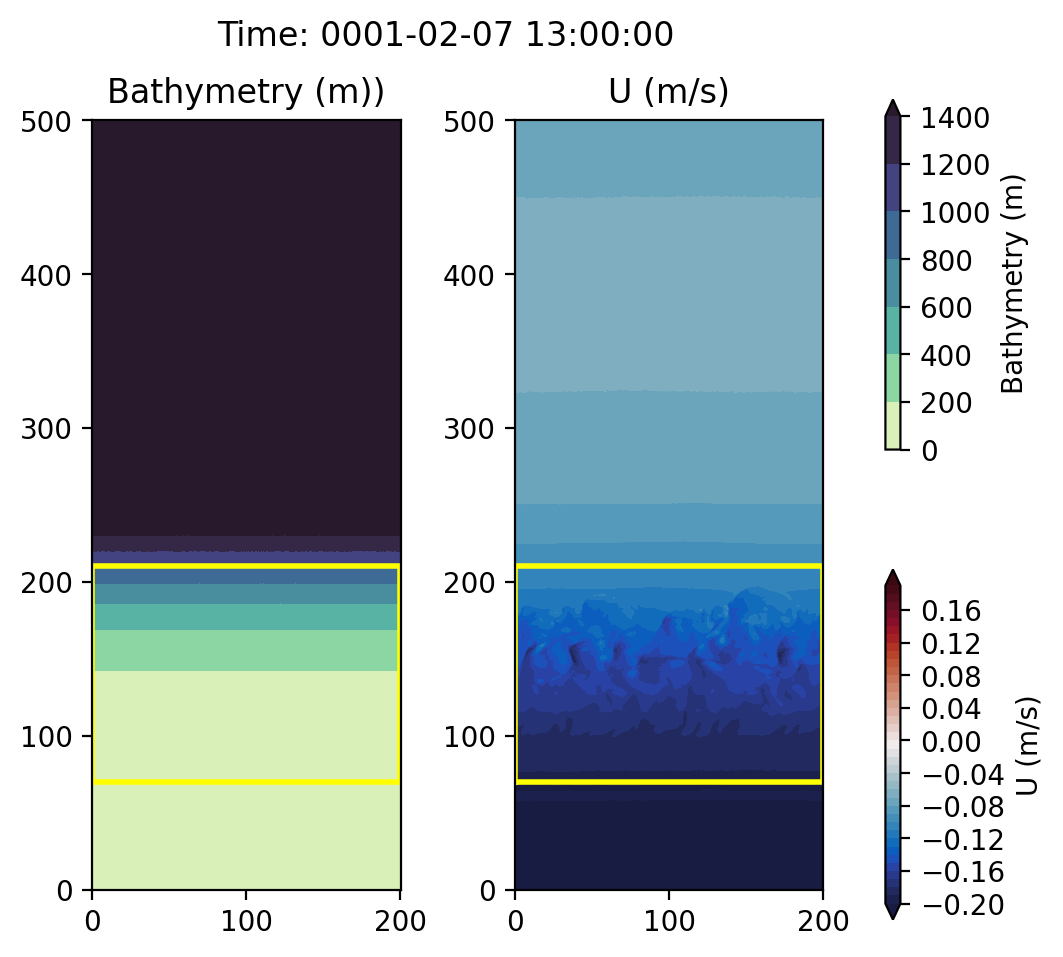

In [7]:
# Plot the domain to make sure we have the right area

# Plot the domain to figure out where we want to take the 
# average in the horizontal 

# Set the time index
time_idx1 = 450

# Make bathymetry levels
lev_bathy = np.arange(10,110,10)
lev_u = np.arange(-0.2, 0.2, 0.01)

# Make the figure 
fig, ax = plt.subplots(1, 2, figsize=(5,5), dpi=200)

# Plot bathymetry
cs1 = ax[0].contourf(x_rho/1000, y_rho/1000, ds_ice_u3c4_keps.h[:,:], cmap=cmo.deep,
                     extend='max')
ax[0].set_title('Bathymetry (m))')
# Make a colorbar 
cbar_ax1 = fig.add_axes([0.94,0.55,0.015,0.35])
fig.colorbar(cs1,ax=ax,extend='both',
             label='Bathymetry (m)',
             pad=0.03, cax=cbar_ax1)

# Plot surface u
cs2 = ax[1].contourf(x_u/1000, y_u/1000, ds_ice_u3c4_keps.u[time_idx1,-1,:,:], 
                     lev_u, cmap=cmo.balance, extend='both')
ax[1].set_title('U (m/s)')
# Make a colorbar 
cbar_ax2 = fig.add_axes([0.94,0.08,0.015,0.35])
fig.colorbar(cs2,ax=ax,extend='both',
             label='U (m/s)',
             pad=0.03, cax=cbar_ax2)

# Add other details to each subplot
for r in range(2):
    # Set aspect ratio
    ax[r].set_aspect(1.0)

# Add the time
fig.suptitle('Time: ' + str(ds_ice_u3c4_keps.ocean_time[time_idx1].values)[0:19])

# Pick a region to analyze 
# Box 1
box_min_x_01 = 0
box_max_x_01 = 200
box_min_y_01 = 70
box_max_y_01 = 210
# Plot Box 1
ax[0].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='yellow', linestyle='-', linewidth=2)
ax[1].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='yellow', linestyle='-', linewidth=2)

fig.canvas.draw()

In [8]:
# Find where these regions are in terms of xi and eta slicing 
# Becuase of periodic boundaries, we want the second to last 
# xi idx and to start at 1 and not 0
box_min_x_01_idx = ((box_min_x_01 * 1000)+dx)/dx
print('box_min_x_01_idx: ', box_min_x_01_idx)
box_max_x_01_idx = ((box_max_x_01 * 1000)-dx)/dx
print('box_max_x_01_idx: ', box_max_x_01_idx)
box_min_y_01_idx = (box_min_y_01 * 1000)/dy
print('box_min_y_01_idx: ', box_min_y_01_idx)
box_max_y_01_idx = (box_max_y_01 * 1000)/dy
print('box_max_y_01_idx: ', box_max_y_01_idx)

xi_slice = slice(int(box_min_x_01_idx), int(box_max_x_01_idx))
eta_slice = slice(int(box_min_y_01_idx), int(box_max_y_01_idx))

box_min_x_01_idx:  1.0
box_max_x_01_idx:  399.0
box_min_y_01_idx:  140.0
box_max_y_01_idx:  420.0


In [9]:
# Set the vertical max
# Note z_rho is negative in ROMS output so it will have 
# a negative sign in front of it when slicing
z_slice = 200 # meters

### Process the Data  
Calculate and save eddy viscosity for the different runs

In [10]:
# Make a function that takes a given ROMS output,
# slices it to w given region, and calculates eddy 
# viscosity 

def calc_eddy_visc(ds_roms, eta_slice, xi_slice, z_slice):
    """
    This function takes a given ROMS output and calculates 
    a PDF of eddy viscosity.

    Inputs:
    - ds_roms: the ROMS dataset, loaded with xroms
    - eta_slice: the indices/slice of the eta region to calculate over
    - xi_slice: the indices/slice of the xi region to calculate over
    - z_slice: The depth above which to caulculate the things (ex: 200)

    Outputs: 
    - roms_visc_pdf: PDF of ROMS vertical eddy viscosity 

    """

    # Get the vertical z points
    z_w = ds_roms.z_w[:980].isel(eta_rho=eta_slice, xi_rho=xi_slice)

    # Get the log10 of the vertical eddy viscosity
    AKv = np.log10(ds_roms.AKv[:980]).isel(eta_rho=eta_slice, xi_rho=xi_slice).where(z_w>-z_slice)
    print('got AKv', flush=True)

    # Make some bins for the PDF
    bins = np.arange(-6.5,-0.5,0.015)

    # Calculate the histogram/PDF
    print('started calculating PDF', flush=True)
    roms_visc_pdf = histogram(AKv, bins=bins, density=True).compute()
    print('done calculating PDF', flush=True)

    # Return the PDF
    return(roms_visc_pdf)


In [11]:
# Call the function for each run
visc_pdf_u3c4_keps = calc_eddy_visc(ds_ice_u3c4_keps, eta_slice, xi_slice, z_slice)
print('done with U3C4, keps')
visc_pdf_u3c4_keps_no_ice = calc_eddy_visc(ds_ice_u3c4_keps_no_ice, eta_slice, xi_slice, z_slice)
print('done with U3C4, keps, no ice')
visc_pdf_u3c4_gen = calc_eddy_visc(ds_ice_u3c4_gen, eta_slice, xi_slice, z_slice)
print('done with U3C4, gen')
visc_pdf_u3c4_kkl = calc_eddy_visc(ds_ice_u3c4_kkl, eta_slice, xi_slice, z_slice)
print('done with U3C4, kkl')
visc_pdf_u3c4_komega = calc_eddy_visc(ds_ice_u3c4_komega, eta_slice, xi_slice, z_slice)
print('done with U3C4, komega')
visc_pdf_u3c4_kpp = calc_eddy_visc(ds_ice_u3c4_kpp, eta_slice, xi_slice, z_slice)
print('done with U3C4, kpp')
visc_pdf_akima_keps = calc_eddy_visc(ds_ice_akima_keps, eta_slice, xi_slice, z_slice)
print('done with akima, keps')
visc_pdf_u3splitc4_keps = calc_eddy_visc(ds_ice_u3splitc4_keps, eta_slice, xi_slice, z_slice)
print('done with U3splitC4, keps')




got AKv
started calculating PDF
done calculating PDF
done with U3C4, keps
got AKv
started calculating PDF
done calculating PDF
done with U3C4, keps, no ice
got AKv
started calculating PDF
done calculating PDF
done with U3C4, gen
got AKv
started calculating PDF
done calculating PDF
done with U3C4, kkl
got AKv
started calculating PDF
done calculating PDF
done with U3C4, komega
got AKv
started calculating PDF
done calculating PDF
done with U3C4, kpp
got AKv
started calculating PDF
done calculating PDF
done with akima, keps
got AKv
started calculating PDF
done calculating PDF
done with U3splitC4, keps


In [12]:
# Need to know the dimensions before saving to netcdf...
visc_pdf_u3c4_keps

<xarray.DataArray 'histogram_AKv' (AKv_bin: 399)> Size: 3kB
array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
...
       4.59281334e-01, 4.86205067e-01, 5.23864656e-01, 5.48922224e-01,
       5.59032901e-01, 5.55528984e-01, 5.12812654e-01, 4.56363730e-01,
       4.16844006e-01, 3.95392921e-01, 3.77074792e-01, 3.49685816e-01,
       3.20143657e-01, 2.92413115e-01, 2.68425308e-01, 2.46072264e-01,
       2.25525158e-01, 2.00332557e-01, 1.78162414e-01, 1.57329609e-01,
       1.45700947e-01, 1.50147943e-01, 1.58827752e-01, 1.56189784e-01,
       1.46003097e-01, 1.45772797e-01, 1.48684840e-01, 1.51409740e-01,
       1.56382338e-01, 1.72928968e-01, 1.88471190e-01, 1.84304566e-01,
       1.73195210e-01, 1.70071724e-01, 1.71026042e-01, 1.84050049e-01,
       2.03976585e-01, 2.06400470e-01, 1.97713546e-01, 1.98944679e-01,
       2.07985479e-01, 2.23201868e-01, 2.25723023e-01, 2.13678338e-01,
       2.06548681e-01, 2.01758616e-01, 1.98063564e-01, 1.92404525e-01,
       1.82209754e-01, 1.83834229e-01, 1.85583248e-01, 1.76786043e-01,
       1.73938102e-01, 1.89232838e-01, 1.96066942e-01, 2.05335119e-01,
       2.43706751e-01, 2.81833771e-01, 2.35340066e-01, 1.85748144e-01,
       1.43653819e-01, 1.19941206e-01, 1.12965254e-01, 1.20295148e-01,
       1.00760467e-01, 1.59572264e-02, 2.29282675e-03, 1.90282524e-04,
       6.53704728e-05, 2.94451057e-05, 1.37956082e-05, 7.46566207e-06,
       4.04181258e-06, 2.48855402e-06, 1.46975003e-06, 9.01892063e-07,
       4.84349441e-07, 1.33613639e-07, 1.67017049e-07])
Coordinates:
  * AKv_bin  (AKv_bin) float64 3kB -6.492 -6.478 -6.463 ... -0.5375 -0.5225

In [13]:
# Make the bins outside of the function to save with 
# the data
bins = np.arange(-6.5,-0.5,0.015)

In [14]:
len(bins)

400

In [15]:
# Save these to a netCDF assuming this will crash or take a long time 
# Save the data to a netcdf

# Variables to save: tke, mke, eke

roms_eddy_visc_pdfs = xr.Dataset(
    data_vars=dict(
        visc_pdf_u3c4_keps=(['AKv_bins'], visc_pdf_u3c4_keps.values),
        visc_pdf_u3c4_keps_no_ice=(['AKv_bins'], visc_pdf_u3c4_keps_no_ice.values),
        visc_pdf_u3c4_gen=(['AKv_bins'], visc_pdf_u3c4_gen.values),
        visc_pdf_u3c4_kkl=(['AKv_bins'], visc_pdf_u3c4_kkl.values),
        visc_pdf_u3c4_komega=(['AKv_bins'], visc_pdf_u3c4_komega.values),
        visc_pdf_u3c4_kpp=(['AKv_bins'], visc_pdf_u3c4_kpp.values),
        visc_pdf_akima_keps=(['AKv_bins'], visc_pdf_akima_keps.values),
        visc_pdf_u3splitc4_keps=(['AKv_bins'], visc_pdf_u3splitc4_keps.values),
    ),
    coords=dict(
        AKv_bins=('AKv_bins', bins[:-1])
    ),
    attrs=dict(description='PDFs of eddy viscosity of different ROMS output from 2-hourly model output')
)

# Add attributes to the 'temperature' data variable
roms_eddy_visc_pdfs['visc_pdf_u3c4_keps'].attrs['long_name'] = 'PDF of eddy viscosity for U3C4, keps'
roms_eddy_visc_pdfs['visc_pdf_u3c4_keps'].attrs['units'] = '$m^{2} s^{-1}$'
roms_eddy_visc_pdfs['visc_pdf_u3c4_keps_no_ice'].attrs['long_name'] = 'PDF of eddy viscosity for U3C4, keps, no ice'
roms_eddy_visc_pdfs['visc_pdf_u3c4_keps_no_ice'].attrs['units'] = '$m^{2} s^{-1}$'
roms_eddy_visc_pdfs['visc_pdf_u3c4_gen'].attrs['long_name'] = 'PDF of eddy viscosity for U3C4, gen'
roms_eddy_visc_pdfs['visc_pdf_u3c4_gen'].attrs['units'] = '$m^{2} s^{-1}$'
roms_eddy_visc_pdfs['visc_pdf_u3c4_kkl'].attrs['long_name'] = 'PDF of eddy viscosity for U3C4, kkl'
roms_eddy_visc_pdfs['visc_pdf_u3c4_kkl'].attrs['units'] = '$m^{2} s^{-1}$'
roms_eddy_visc_pdfs['visc_pdf_u3c4_komega'].attrs['long_name'] = 'PDF of eddy viscosity for U3C4, komega'
roms_eddy_visc_pdfs['visc_pdf_u3c4_komega'].attrs['units'] = '$m^{2} s^{-1}$'
roms_eddy_visc_pdfs['visc_pdf_u3c4_kpp'].attrs['long_name'] = 'PDF of eddy viscosity for U3C4, kpp'
roms_eddy_visc_pdfs['visc_pdf_u3c4_kpp'].attrs['units'] = '$m^{2} s^{-1}$'
roms_eddy_visc_pdfs['visc_pdf_akima_keps'].attrs['long_name'] = 'PDF of eddy viscosity for akima, keps'
roms_eddy_visc_pdfs['visc_pdf_akima_keps'].attrs['units'] = '$m^{2} s^{-1}$'
roms_eddy_visc_pdfs['visc_pdf_u3splitc4_keps'].attrs['long_name'] = 'PDF of eddy viscosity for U3splitC4, keps'
roms_eddy_visc_pdfs['visc_pdf_u3splitc4_keps'].attrs['units'] = '$m^{2} s^{-1}$'

# Save to a netcdf
#roms_eddy_visc_pdfs.to_netcdf('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_eddy_visc_pdf_all_runs_001.nc')


In [16]:
# Make the colors to use 
run_colors_all = ["#fec64e", 'dimgrey', '#56b4e9', '#009e73', '#0072b2', '#d55e00', '#e377c2', '#4eab58', '#db6d00', '#d628c1']


(0.0001, 10)

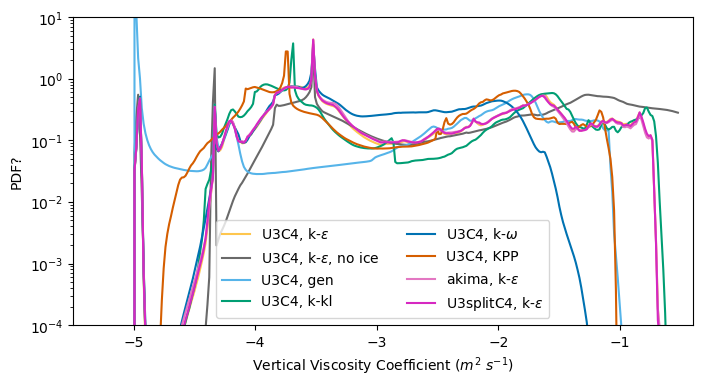

In [28]:
# Plot these!

# Make the figure
fig, ax=plt.subplots(1, 1, figsize=(8,4), dpi=100)

# Plot the different PDFs
visc_pdf_u3c4_keps.plot(color=run_colors_all[0], label = 'U3C4, k-$\epsilon$')
visc_pdf_u3c4_keps_no_ice.plot(color=run_colors_all[1], label = 'U3C4, k-$\epsilon$, no ice')
visc_pdf_u3c4_gen.plot(color=run_colors_all[2], label = 'U3C4, gen')
visc_pdf_u3c4_kkl.plot(color=run_colors_all[3], label = 'U3C4, k-kl')
visc_pdf_u3c4_komega.plot(color=run_colors_all[4], label = 'U3C4, k-$\omega$')
visc_pdf_u3c4_kpp.plot(color=run_colors_all[5], label = 'U3C4, KPP')
visc_pdf_akima_keps.plot(color=run_colors_all[6], label = 'akima, k-$\epsilon$')
#visc_pdf_hsimt_keps.plot(color=run_colors_all[7], label = 'HSIMT, k-$\epsilon$')
#visc_pdf_mpdata_keps.plot(color=run_colors_all[8], label = 'MPDATA, k-$\epsilon$')
visc_pdf_u3splitc4_keps.plot(color=run_colors_all[9], label = 'U3splitC4, k-$\epsilon$')

# Put the plot on log scale 
plt.semilogy()

# Add a legend 
plt.legend(ncols=2)

# Label the axes
ax.set_xlabel('Vertical Viscosity Coefficient ($m^{2}$ $s^{-1}$)')
ax.set_ylabel('PDF?')

# Set axis limits 
plt.xlim(-5.5,-.4)
plt.ylim(1e-4,10)


In [ ]:
# Example code
xislice = slice(1,-1)
etaslice = slice(100,400)

z_w = ds_keps.z_w[108:150].isel(eta_rho = etaslice, xi_rho = xislice)
Akv = np.log10(ds_keps.AKv[108:150]).isel(eta_rho = etaslice, xi_rho = xislice).where(z_w>-200)
bins = np.arange(-6.5,-0.5,0.015)

keps_pdf = histogram(Akv,bins=[bins],density=True).compute()

z_w = ds_kpp.z_w[108:150].isel(eta_rho = etaslice, xi_rho = xislice)
Akv = np.log10(ds_kpp.AKv[108:150]).isel(eta_rho = etaslice, xi_rho = xislice).where(z_w>-200)

kpp_pdf = histogram(Akv,bins=[bins],density=True).compute()

fig,ax=plt.subplots(1,1,figsize=(5,3),dpi=100)
kpp_pdf.plot(label = 'KPP')
keps_pdf.plot(label = r'$k-\epsilon$')
plt.semilogy()
plt.legend()
plt.xlim(-5.5,-.5)
plt.ylim(1e-4,10)
